In [5]:
from langgraph.graph import StateGraph, START, END
from langchain_groq import ChatGroq
from dotenv import load_dotenv
from typing import TypedDict

In [6]:
load_dotenv() # Load environment variables from .env file

True

In [7]:
LLM = ChatGroq(model = "openai/gpt-oss-120b", temperature = 0.7)

In [17]:
# state
class blogllm(TypedDict):
    title: str
    outline: str
    content: str
    score: int

In [18]:
def topic_generatorllm(state: blogllm) -> blogllm:
    # taking the topic state
    title = state['title']
    
    prompt = f"give me a outline around this title: {title}"
    
    outline = LLM.invoke(prompt).content
    
    state['outline'] = outline
    
    return state
    

In [19]:
def blog_generatorllm(state: blogllm) -> blogllm:
    # taking the outline from state
    outline = state['outline']
    
    prompt = f"write a detailed blog around this outline: {outline}"
    
    content = LLM.invoke(prompt).content
    
    state['content'] = content
    
    return state

In [20]:
def content_evaluation(state: blogllm)-> blogllm:
    # taking the content from state
    content = state['content']
    
    prompt = f"evaluate the content: {content} and give me a score out of 10"
    
    score = LLM.invoke(prompt).content
    
    state['score'] = score
    
    return state

In [21]:
# graph
graph = StateGraph(blogllm)

# nodes
graph.add_node("topic_generation", topic_generatorllm)
graph.add_node("blog_generation", blog_generatorllm)
graph.add_node("content_evaluation", content_evaluation)

# edges
graph.add_edge(START, "topic_generation")
graph.add_edge("topic_generation", "blog_generation")
graph.add_edge("blog_generation", "content_evaluation")
graph.add_edge("content_evaluation", END)

# compile
workflow = graph.compile()


In [22]:
# execution
initial_state = {"title": "The Future of Artificial Intelligence: Trends and Predictions"}

output_state = workflow.invoke(initial_state)


In [23]:
print("Title:", output_state['title'])

Title: The Future of Artificial Intelligence: Trends and Predictions


In [24]:
print("Outline:", output_state['outline'])

Outline: **Outline – “The Future of Artificial Intelligence: Trends and Predictions”**

---

### I. Introduction  
   A. Brief recap of AI’s evolution (from rule‑based systems to deep learning)  
   B. Why looking ahead matters – economic, societal, and ethical stakes  
   C. Scope & methodology of the analysis (literature review, expert surveys, market data)

### II. Current State of AI (2024 Snapshot)  
   A. Technological milestones  
      1. Large language models (LLMs) and multimodal systems  
      2. Foundation models in vision, speech, and robotics  
   B. Market landscape  
      1. Global AI spending & investment trends  
      2. Dominant players & emerging startups  
   C. Regulatory environment  
      1. Major frameworks (EU AI Act, US AI Bill of Rights, China’s AI Governance)  
      2. Industry self‑regulation initiatives  

### III. Key Technological Trends Shaping the Future  

| Trend | Core Development | Near‑Term Impact (1‑3 yr) | Mid‑Term Impact (3‑7 yr) |
|-----

In [25]:
print("content", output_state['content'])

content # The Future of Artificial Intelligence: Trends and Predictions  

*By [Your Name] – July 2026*  

> **TL;DR** – AI is moving from “big‑model‑as‑service” to “tiny‑model‑as‑every‑thing.” Over the next decade we’ll see foundation models become universal adapters, edge‑AI turn into everyday appliances, and trustworthy‑AI standards become the rule rather than the exception. The upside is massive productivity gains and new industries; the downside is concentration of power, new kinds of bias, and geopolitical friction.  

---

## I. Introduction  

### A. From Rule‑Based Systems to Deep Learning – A 70‑Year Sprint  

| Era | Dominant Paradigm | Hallmark Achievement |
|-----|-------------------|----------------------|
| 1950‑70s | Symbolic AI / Expert Systems | ELIZA, MYCIN – knowledge encoded by hand |
| 1980‑90s | Connectionist Revival | Back‑propagation, early neural nets |
| 2000‑10s | Statistical Machine Learning | SVMs, Random Forests, the “big data” boom |
| 2010‑2020 | Deep L

In [29]:
print(output_state['score'])

**Evaluation of the Draft “The Future of Artificial Intelligence: Trends and Predictions”**  

**Overall Score: 8 / 10**

| Dimension | Rating | Comments |
|-----------|--------|----------|
| **Structure & Organization** | 9 | The piece follows a clear, logical flow (intro → snapshot → trends → sector outlook → socio‑economic impact → governance). The use of tables, bullet points, and TL;DR makes it skimmable for busy readers. |
| **Depth & Breadth of Content** | 8 | Covers the major technical milestones, market data, regulatory environment, and sector‑specific forecasts. The inclusion of emerging areas (tiny‑AI, quantum‑enhanced AI) shows forward‑looking thinking. |
| **Evidence & Credibility** | 7 | References to reputable sources (McKinsey, IDC, Nature Machine Intelligence, EU AI Act) are good, but many claims would benefit from explicit citations (e.g., “84 AI researchers surveyed”). Adding footnotes or a bibliography would raise academic rigor. |
| **Clarity & Readability** | 8 | 

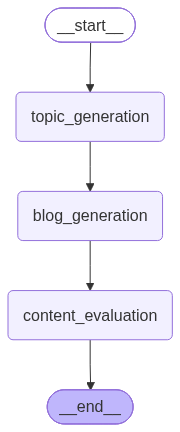

In [26]:
# visualization
from IPython.display import Image
Image(workflow.get_graph().draw_mermaid_png())